In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('ushape.csv' , header=None , names= ['X1' , 'X2' , 'Y'])

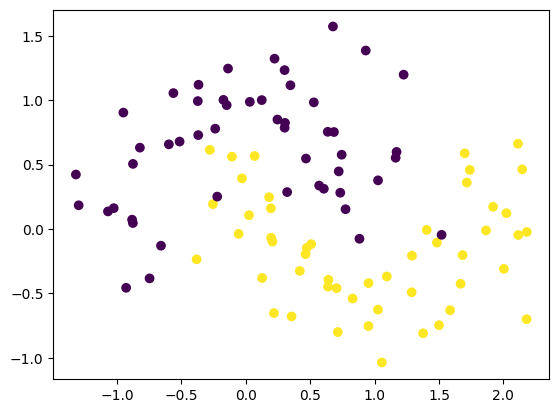

In [3]:
plt.scatter(x = df.iloc[: , 0] , y = df.iloc[: , 1] , c = df.iloc[: , 2])

In [4]:
X= df.iloc[: , 0 : 2].values
y = df.iloc[: , -1].values

In [5]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

2025-12-24 15:34:03.014853: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-24 15:34:03.036707: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766590443.060246    7828 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766590443.069618    7828 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766590443.090764    7828 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [6]:
model = Sequential()

model.add(Dense(10 , activation='relu' , input_dim = 2 , kernel_initializer='he_normal'))
model.add(Dense(10 , activation='relu' ,  kernel_initializer='he_normal'))
model.add(Dense(10 , activation='relu' ,  kernel_initializer='he_normal'))
model.add(Dense(10 , activation='relu' ,  kernel_initializer='he_normal'))
model.add(Dense(1 , activation='sigmoid' ))

model.summary()

/home/subhamoy/miniforge3/envs/tf_gpu/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1766590519.090800    7828 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1507 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(loss = 'binary_crossentropy' , optimizer='adam' , metrics=['accuracy'])

In [8]:
model.get_weights()

[array([[-0.4600561 ,  0.11149042, -0.50294554, -0.8459536 , -1.790388  ,
          1.0184257 ,  0.5788903 ,  1.7975011 , -1.1420748 ,  0.7020944 ],
        [-1.0820239 , -1.049014  ,  0.48876047,  0.5885796 ,  0.5479298 ,
         -0.9275237 , -1.0582525 ,  1.7740949 , -1.3835979 ,  0.02128262]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.64924437, -0.03090398,  0.02133742,  0.46775562,  0.7420219 ,
         -0.98924047, -0.00368484, -0.19586632, -0.60087377, -0.36291015],
        [ 0.20100608,  0.26820597, -0.8383313 , -0.6537553 , -0.44282803,
         -0.8070337 ,  0.35197595, -0.54870564, -0.7244048 ,  0.04539712],
        [ 0.91607934,  0.20630068,  0.45233798,  0.859278  , -0.01777121,
         -0.5269782 , -0.2864294 , -0.6085168 , -0.16647393,  0.34683222],
        [-0.088197  , -0.6929236 ,  0.47819403, -0.5534554 ,  0.23159547,
         -0.04195358, -0.26907346,  0.15974593, -0.4752945 ,  0.05351981],
        [ 0.11883

In [9]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100


I0000 00:00:1766590570.829058    7941 service.cc:152] XLA service 0x7721780075c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766590570.829111    7941 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4060, Compute Capability 8.9
2025-12-24 15:36:10.860882: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1766590571.096229    7941 cuda_dnn.cc:529] Loaded cuDNN version 91301


1/3 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.6250 - loss: 0.6657

I0000 00:00:1766590571.765655    7941 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 576ms/step - accuracy: 0.5000 - loss: 0.6898 - val_accuracy: 0.5000 - val_loss: 0.6534
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5000 - loss: 0.6871 - val_accuracy: 0.5000 - val_loss: 0.6497
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5000 - loss: 0.6845 - val_accuracy: 0.5500 - val_loss: 0.6455
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5250 - loss: 0.6821 - val_accuracy: 0.6000 - val_loss: 0.6415
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5250 - loss: 0.6795 - val_accuracy: 0.6500 - val_loss: 0.6373
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5625 - loss: 0.6778 - val_accuracy: 0.6500 - val_loss: 0.6331
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5750 - loss: 0.6754 - val_accuracy: 0.7500 - val_loss: 0.6287
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6000 - loss: 0.6733 - val_accuracy: 0.8000 - val_loss: 0.6244
Epo